In [1]:
import re
import nltk
import pandas as pd

from nltk.corpus import stopwords
from sklearn.datasets import fetch_20newsgroups
from sklearn.model_selection import train_test_split

nltk.download("stopwords")

stemmer = nltk.stem.SnowballStemmer("english")
english_stopwords = set(stopwords.words("english"))
from IPython.display import display

from sklearn.feature_extraction.text import CountVectorizer, TfidfVectorizer
from sklearn.naive_bayes import MultinomialNB
from sklearn.linear_model import SGDClassifier

from sklearn.metrics import accuracy_score, classification_report

from sklearn.model_selection import train_test_split
import matplotlib.pyplot as plt

[nltk_data] Downloading package stopwords to
[nltk_data]     C:\Users\adwar\AppData\Roaming\nltk_data...
[nltk_data]   Package stopwords is already up-to-date!


# Clasificación temática: 20 Newsgroups


In [2]:
newsgroups = fetch_20newsgroups(
    subset="all",
    remove=("headers", "footers", "quotes"),
    random_state=0
)

print("Número de documentos:", len(newsgroups.data))
print("Número de clases:", len(newsgroups.target_names))

Número de documentos: 18846
Número de clases: 20


In [3]:
news_df = pd.DataFrame({
    "text": newsgroups.data,
    "label": newsgroups.target
})

news_df["label_name"] = news_df["label"].map(dict(enumerate(newsgroups.target_names)))

news_df.head()

,text,label,label_name
0,FOR SALE\n\n 1945 King Feature...,6,misc.forsale
1,Earlier today I read an ad for REAL-3D animati...,1,comp.graphics
2,Can someone cite Biblical references to homose...,15,soc.religion.christian
3,My friends and I have a buch of books for sale...,6,misc.forsale
4,\n\nThey are using some technology developed b...,11,sci.crypt


In [4]:
newsgroups.target_names

['alt.atheism',
 'comp.graphics',
 'comp.os.ms-windows.misc',
 'comp.sys.ibm.pc.hardware',
 'comp.sys.mac.hardware',
 'comp.windows.x',
 'misc.forsale',
 'rec.autos',
 'rec.motorcycles',
 'rec.sport.baseball',
 'rec.sport.hockey',
 'sci.crypt',
 'sci.electronics',
 'sci.med',
 'sci.space',
 'soc.religion.christian',
 'talk.politics.guns',
 'talk.politics.mideast',
 'talk.politics.misc',
 'talk.religion.misc']

In [5]:
news_df["label_name"].value_counts().sort_index()

label_name
alt.atheism                 799
comp.graphics               973
comp.os.ms-windows.misc     985
comp.sys.ibm.pc.hardware    982
comp.sys.mac.hardware       963
comp.windows.x              988
misc.forsale                975
rec.autos                   990
rec.motorcycles             996
rec.sport.baseball          994
rec.sport.hockey            999
sci.crypt                   991
sci.electronics             984
sci.med                     990
sci.space                   987
soc.religion.christian      997
talk.politics.guns          910
talk.politics.mideast       940
talk.politics.misc          775
talk.religion.misc          628
Name: count, dtype: int64

- Cantidad de documentos por clase.

## Procesamiento de texto

In [6]:
def preprocess(text):
    """Limpia y procesa un mensaje en inglés."""

    processed = re.sub(r"\W", " ", str(text))
    processed = re.sub(r"\s+[a-zA-Z]\s+", " ", processed)
    processed = re.sub(r"[0-9]+", " ", processed)
    processed = re.sub(r" +", " ", processed)
    processed = processed.lower()
    return " ".join(
        stemmer.stem(token)
        for token in processed.split()
        if token not in english_stopwords
    )

In [7]:
news_df["processed_text"] = [
    preprocess(text)
    for text in news_df["text"]
]

In [8]:
news_df.head()

,text,label,label_name,processed_text
0,FOR SALE\n\n 1945 King Feature...,6,misc.forsale,sale king featur syndic jaymar specialti compa...
1,Earlier today I read an ad for REAL-3D animati...,1,comp.graphics,earlier today read ad real anim ray trace soft...
2,Can someone cite Biblical references to homose...,15,soc.religion.christian,someon cite biblic refer homosexu immor leviti...
3,My friends and I have a buch of books for sale...,6,misc.forsale,friend buch book sale use due chang job loss i...
4,\n\nThey are using some technology developed b...,11,sci.crypt,use technolog develop vlsi system manufactur c...


### Visualización de los textos procesados

In [9]:
n_ejemplos = 5

ejemplos = (
    news_df[["text", "processed_text"]]
    .sample(n=n_ejemplos)
    .reset_index(drop=True)
    .copy()
)

ejemplos = ejemplos.rename(columns={
    "text": "Texto original",
    "processed_text": "Texto procesado"
})

display(
    ejemplos.style
    .set_properties(**{
        "white-space": "pre-wrap",
        "text-align": "left",
        "vertical-align": "top",
        "font-size": "14px",
        "padding": "12px"
    })
    .set_table_styles([
        {
            "selector": "table",
            "props": [
                ("width", "100%"),
                ("table-layout", "fixed")
            ]
        },
        {
            "selector": "th",
            "props": [
                ("text-align", "center"),
                ("font-size", "15px"),
                ("padding", "12px")
            ]
        }
    ])
)

,Texto original,Texto procesado
0,"What tube does the Viewsonic 17 use? Does is support 1600x1280? I've been looking a a Philips 1762DT which uses a Sony Trinitron tube, has digital controls, supports up to 1280x1024NI, and has .25mm dot pitch - It can be found for under $1000.",tube viewson use support x look philip dt use soni trinitron tube digit control support x ni mm dot pitch found
1,"# Mr. Cramer, I am still waiting for your response to my requests regarding # the information you claim to have. I respectfully request that you either # provide the information or withdraw the various assertions you make below. # # Item number 1: in a previous posting, you stated that you had found # ""overwhelming support for child molestation"" in soc.motss: # # You have (finally) responded to this one. I have read your complete file # of postings to soc.motss and to put it bluntly, it does not support your # assertion. In short, this claim is bogus. Thank you for confirming this. All those postings in defense of adults having sex with children, and you just choose to claim that they don't say anything of the sort. There's no point in discussing this any further, then. You are clearly a liar, without morals of any sort, prepared to justify child molestation.",mr cramer still wait respons request regard inform claim respect request either provid inform withdraw various assert make item number previous post state found overwhelm support child molest soc motss final respond one read complet file post soc motss put blunt support assert short claim bogus thank confirm post defens adult sex children choos claim say anyth sort point discuss clear liar without moral sort prepar justifi child molest
2,"Its just variation within a thread. The variation at times has been so great that speciation has occurred. So Albert Sabin is the common ancestor of several threads, some of which have themselves speciated. On a separate topic, I subscribed to t.o. just recently. Albert Sabin existed at that time, so I have no clue as to its origins. Maybe the abiogenesists have an answer. I might also point out that evolution is aimless. Thus why Albert Sabin evolved into a religious discussion is probably unexplainable.",variat within thread variat time great speciat occur albert sabin common ancestor sever thread speciat separ topic subscrib recent albert sabin exist time clue origin mayb abiogenesist answer might also point evolut aimless thus albert sabin evolv religi discuss probabl unexplain
3,"The Delaunay triangulation is the geometrical dual of the Voronoi tessellation and both constructions are derived from natural neighbor order. Aurenhammer, F., 1991, Voronoi Diagrams - A Survey of a Fundamental Geometric Data Structure: ACM Computing Surveys, 23(3), p. 345-405. Okabe, A., Boots, B., and Sugihara, K., 1992, Spatial tessellations : concepts and applications of Voronoi diagrams: Wiley & Sons, New York, ISBN 0 471 93430 5, 532p. Watson, D.F., 1981, Computing the n-dimensional Delaunay tessellation with application to Voronoi polytopes: The Computer J., 24(2), p. 167-172.} Watson, D.F., 1985, Natural neighbour sorting: The Australian Computer J., 17(4), p. 189-193.",delaunay triangul geometr dual voronoi tessel construct deriv natur neighbor order aurenhamm voronoi diagram survey fundament geometr data structur acm comput survey okab boot sugihara spatial tessel concept applic voronoi diagram wiley son new york isbn p watson f comput dimension delaunay tessel applic voronoi polytop comput watson f natur neighbour sort australian comput
4,"Why do you insist on reposting the entire original post? Don't waste bandwidth, please. You know how picky us non- Jews can be. Ha Ha. :|",insist repost entir origin post wast bandwidth pleas know picki us non jew ha ha


### Particiones 60% - 10% - 30%

In [10]:
train_df, temp_df = train_test_split(
    news_df,
    test_size=0.40,
    random_state=0,
    stratify=news_df["label"]
)

test_df, val_df = train_test_split(
    temp_df,
    test_size=0.25,
    random_state=0,
    stratify=temp_df["label"]
)

In [11]:
print("Total:", len(news_df))
print("Entrenamiento:", len(train_df))
print("Validación:", len(val_df))
print("Prueba:", len(test_df))

print("Entrenamiento:", len(train_df) / len(news_df))
print("Validación:", len(val_df) / len(news_df))
print("Prueba:", len(test_df) / len(news_df))

Total: 18846
Entrenamiento: 11307
Validación: 1885
Prueba: 5654
Entrenamiento: 0.5999681630054123
Validación: 0.10002122466305848
Prueba: 0.30001061233152926


In [12]:
distribucion = pd.DataFrame({
    "Entrenamiento": train_df["label_name"].value_counts(),
    "Validación": val_df["label_name"].value_counts(),
    "Prueba": test_df["label_name"].value_counts()
})

distribucion = distribucion.reindex(newsgroups.target_names)


In [13]:
distribucion.loc["TOTAL"] = distribucion.sum()

distribucion

,Entrenamiento,Validación,Prueba
label_name,,,
alt.atheism,479,80,240
comp.graphics,584,97,292
comp.os.ms-windows.misc,591,98,296
comp.sys.ibm.pc.hardware,589,98,295
comp.sys.mac.hardware,578,96,289
comp.windows.x,593,99,296
misc.forsale,585,97,293
rec.autos,594,99,297
rec.motorcycles,598,100,298


## Modelos y representaciones.

In [14]:
y_train = train_df["label_name"].to_numpy()
y_val = val_df["label_name"].to_numpy()
y_test = test_df["label_name"].to_numpy()

Función auxiliar para generar las gráficas de las métricas

In [34]:
def graficar_reporte_clasificacion(y_real, y_pred, titulo):
    reporte = classification_report(
        y_real,
        y_pred,
        digits=4,
        output_dict=True
    )

    df_reporte = pd.DataFrame(reporte).T

    df_clases = df_reporte.drop(
        index=["accuracy", "macro avg", "weighted avg"],
        errors="ignore"
    )

    nombres_cortos = [
        nombre[:12] + "..." if len(nombre) > 12 else nombre
        for nombre in df_clases.index
    ]

    ax = df_clases[
        ["precision", "recall", "f1-score"]
    ].plot(
        kind="bar",
        figsize=(16, 7),
        width=0.8
    )

    ax.set_title(titulo)
    ax.set_xlabel("Clase")
    ax.set_ylabel("Puntuación")
    ax.set_ylim(0, 1)

    ax.set_xticklabels(
        nombres_cortos,
        rotation=45,
        ha="right",
        fontsize=9
    )

    ax.legend(
        title="Métrica",
        bbox_to_anchor=(1.02, 1),
        loc="upper left"
    )

    plt.tight_layout()
    plt.show()

    return df_reporte

### CountVectorizer

In [15]:
count_vectorizer = CountVectorizer(
    max_features=2500
)

X_train_count = count_vectorizer.fit_transform(
    train_df["processed_text"]
)

X_val_count = count_vectorizer.transform(
    val_df["processed_text"]
)

print("Train:", X_train_count.shape)
print("Validación:", X_val_count.shape)

Train: (11307, 2500)
Validación: (1885, 2500)


### TF-IDF

In [16]:
tfidf_vectorizer = TfidfVectorizer(
    max_features=2500
)

X_train_tfidf = tfidf_vectorizer.fit_transform(
    train_df["processed_text"]
)

X_val_tfidf = tfidf_vectorizer.transform(
    val_df["processed_text"]
)

print("Train:", X_train_tfidf.shape)
print("Validación:", X_val_tfidf.shape)

Train: (11307, 2500)
Validación: (1885, 2500)


### CountVectorizer + Naive Bayes

In [17]:
nb_count = MultinomialNB()

nb_count.fit(
    X_train_count,
    y_train
)

pred_nb_count = nb_count.predict(
    X_val_count
)

acc_nb_count = accuracy_score(
    y_val,
    pred_nb_count
)

print("Accuracy:", acc_nb_count)

Accuracy: 0.6249336870026525


In [31]:
reporte = classification_report(
    y_val,
    pred_nb_count,
    digits=4,
    output_dict=True
)

df_reporte = pd.DataFrame(reporte).T

df_reporte = df_reporte.rename(
    columns={
        "support": "n_validacion"
    }
)
df_reporte["n_validacion"] = (
    df_reporte["n_validacion"]
    .round()
    .astype(int)
)
df_reporte

,precision,recall,f1-score,n_validacion
alt.atheism,0.464646,0.575000,0.513966,80
comp.graphics,0.568627,0.597938,0.582915,97
comp.os.ms-windows.misc,0.666667,0.020408,0.039604,98
comp.sys.ibm.pc.hardware,0.476562,0.622449,0.539823,98
comp.sys.mac.hardware,0.582677,0.770833,0.663677,96
comp.windows.x,0.568182,0.757576,0.649351,99
misc.forsale,0.845238,0.731959,0.784530,97
rec.autos,0.627451,0.646465,0.636816,99
rec.motorcycles,0.616822,0.660000,0.637681,100
rec.sport.baseball,0.712963,0.770000,0.740385,100


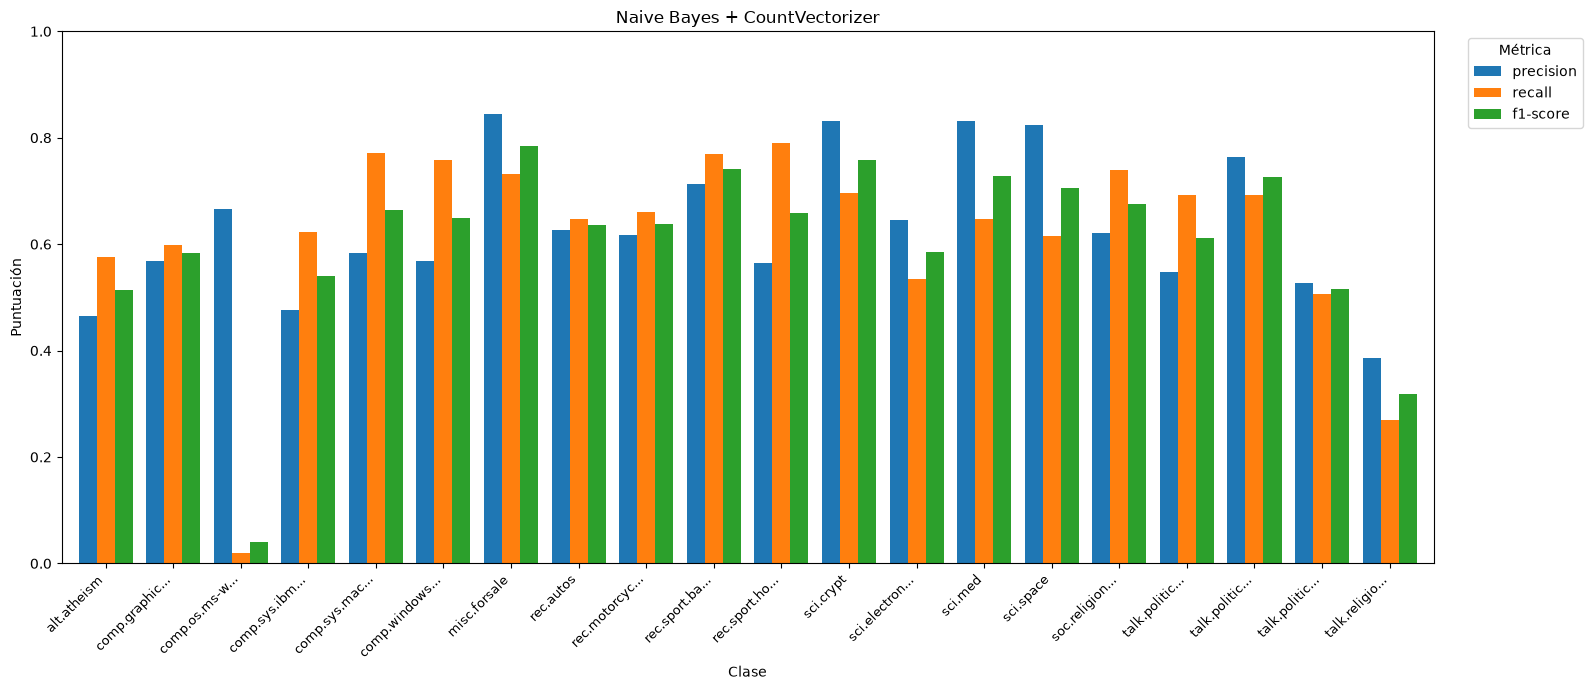

In [35]:
df_reporte_nb_count = graficar_reporte_clasificacion(
    y_val,
    pred_nb_count,
    "Naive Bayes + CountVectorizer"
)

### CountVectorizer + regresión logística

In [33]:
lr_count = SGDClassifier(
    loss="log_loss",
    learning_rate="constant",
    eta0=0.0001,
    random_state=0
)

lr_count.fit(
    X_train_count,
    y_train
)

pred_lr_count = lr_count.predict(
    X_val_count
)

acc_lr_count = accuracy_score(
    y_val,
    pred_lr_count
)

print("Accuracy:", acc_lr_count)

Accuracy: 0.6026525198938992


In [21]:
print(
    classification_report(
        y_val,
        pred_lr_count,
        digits=4
    )
)

                          precision    recall  f1-score   support

             alt.atheism     0.3929    0.4125    0.4024        80
           comp.graphics     0.5204    0.5258    0.5231        97
 comp.os.ms-windows.misc     0.6044    0.5612    0.5820        98
comp.sys.ibm.pc.hardware     0.5424    0.6531    0.5926        98
   comp.sys.mac.hardware     0.7215    0.5938    0.6514        96
          comp.windows.x     0.6923    0.6364    0.6632        99
            misc.forsale     0.7204    0.6907    0.7053        97
               rec.autos     0.4453    0.5758    0.5022        99
         rec.motorcycles     0.8095    0.5100    0.6258       100
      rec.sport.baseball     0.7073    0.5800    0.6374       100
        rec.sport.hockey     0.8280    0.7700    0.7979       100
               sci.crypt     0.7191    0.6465    0.6809        99
         sci.electronics     0.5046    0.5556    0.5288        99
                 sci.med     0.6034    0.7071    0.6512        99
         

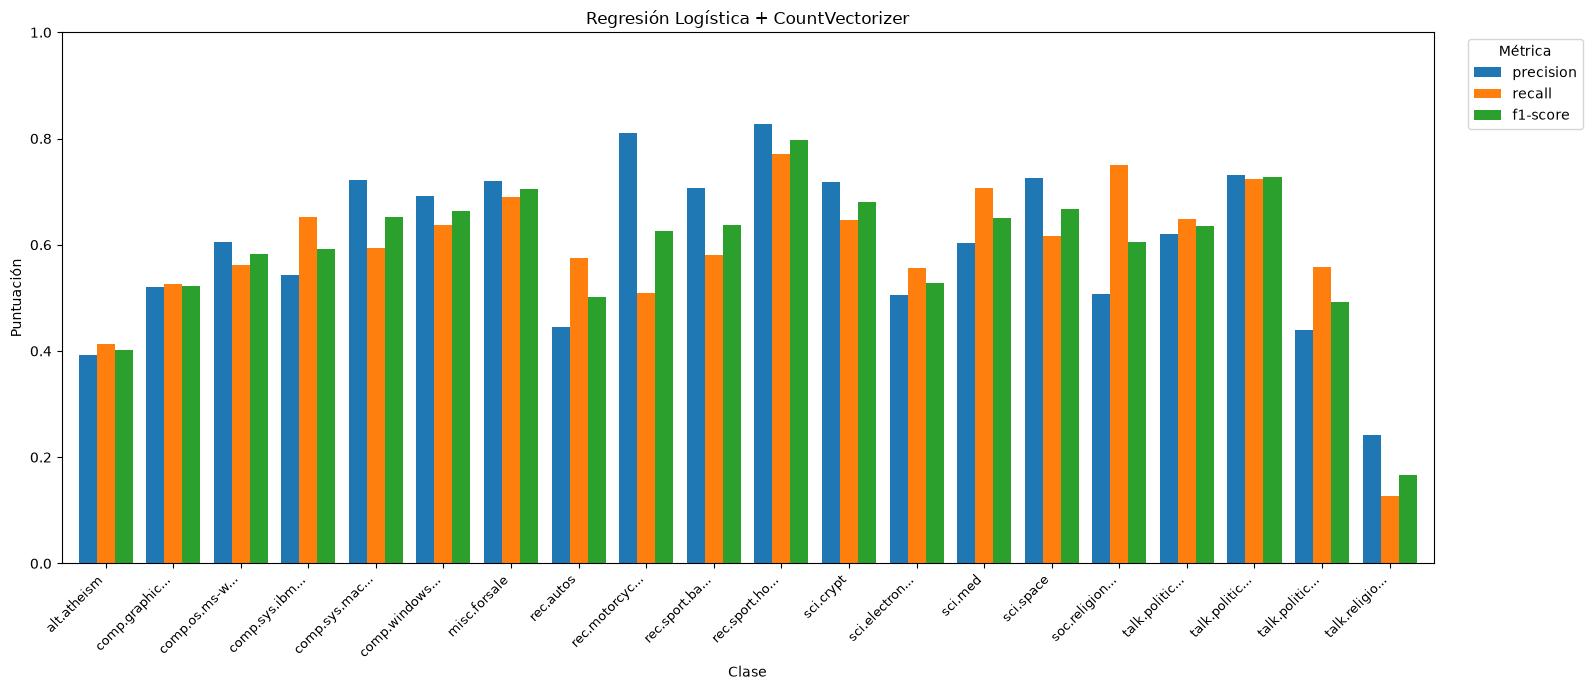

In [36]:
df_reporte_lr_count = graficar_reporte_clasificacion(
    y_val,
    pred_lr_count,
    "Regresión Logística + CountVectorizer"
)

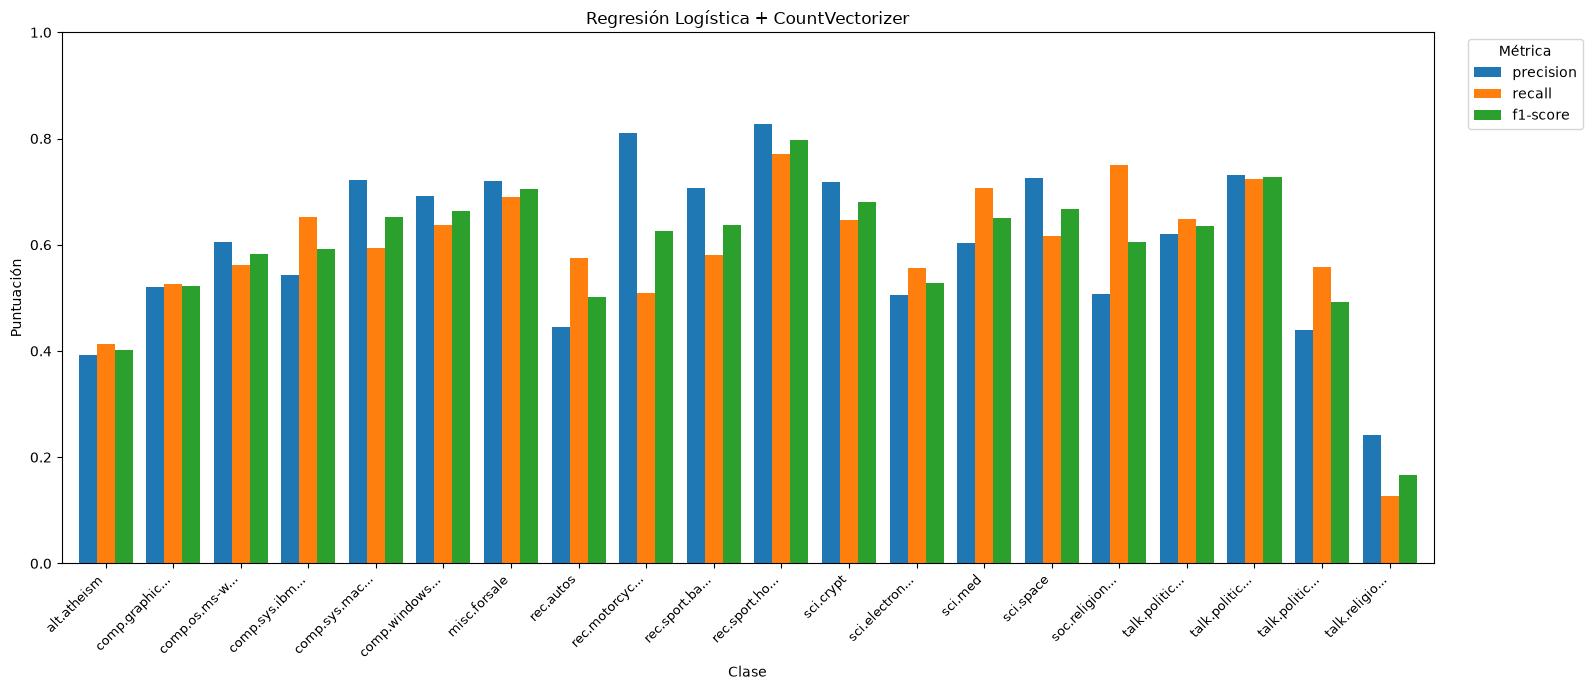

## TF-IDF + Naive Bayes

In [23]:
nb_tfidf = MultinomialNB()

nb_tfidf.fit(
    X_train_tfidf,
    y_train
)

pred_nb_tfidf = nb_tfidf.predict(
    X_val_tfidf
)

acc_nb_tfidf = accuracy_score(
    y_val,
    pred_nb_tfidf
)

print("Accuracy:", acc_nb_tfidf)

Accuracy: 0.6641909814323608


In [24]:
print(
    classification_report(
        y_val,
        pred_nb_tfidf,
        digits=4
    )
)

                          precision    recall  f1-score   support

             alt.atheism     0.5593    0.4125    0.4748        80
           comp.graphics     0.5648    0.6289    0.5951        97
 comp.os.ms-windows.misc     0.6211    0.6020    0.6114        98
comp.sys.ibm.pc.hardware     0.6126    0.6939    0.6507        98
   comp.sys.mac.hardware     0.6923    0.6562    0.6738        96
          comp.windows.x     0.6909    0.7677    0.7273        99
            misc.forsale     0.8605    0.7629    0.8087        97
               rec.autos     0.6737    0.6465    0.6598        99
         rec.motorcycles     0.7033    0.6400    0.6702       100
      rec.sport.baseball     0.8041    0.7800    0.7919       100
        rec.sport.hockey     0.5548    0.8600    0.6745       100
               sci.crypt     0.7527    0.7071    0.7292        99
         sci.electronics     0.6456    0.5152    0.5730        99
                 sci.med     0.7727    0.6869    0.7273        99
         

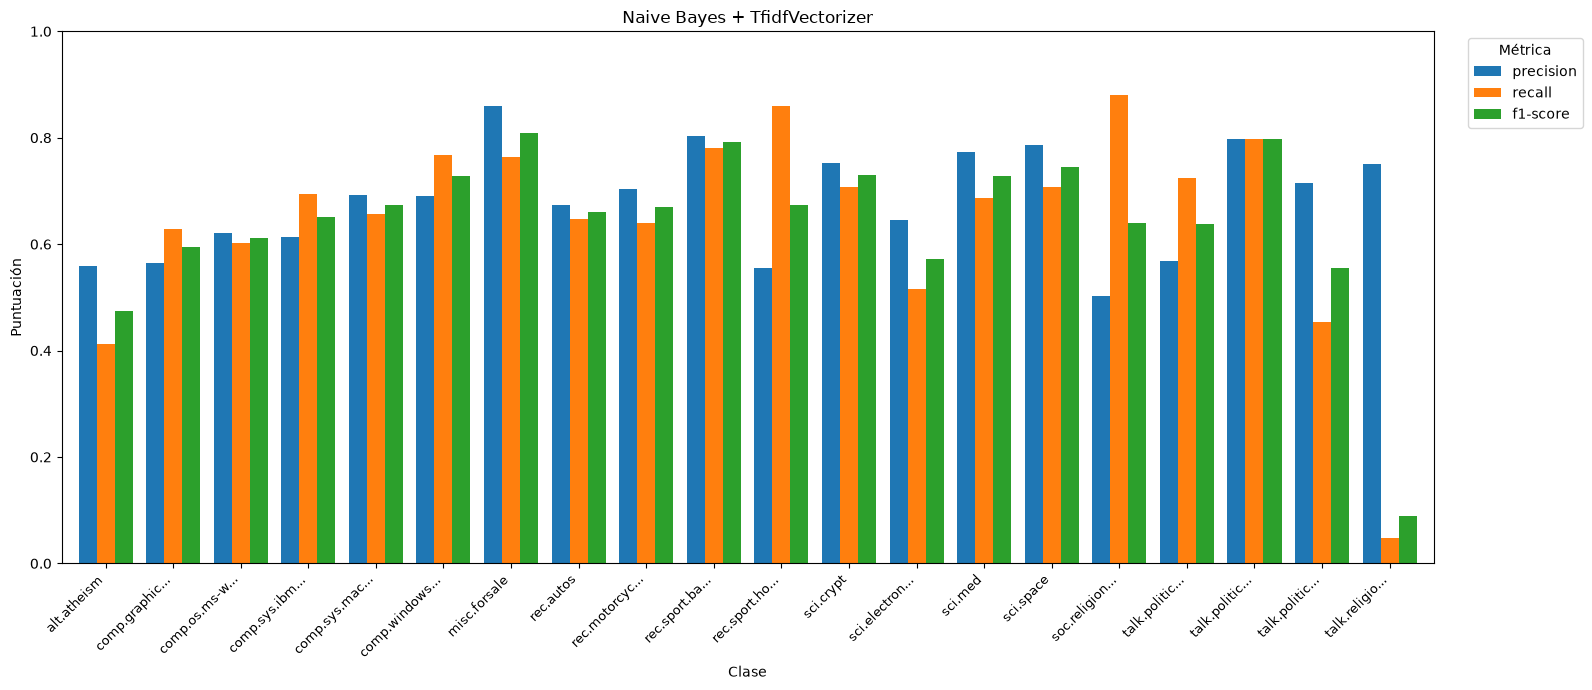

In [37]:
df_reporte_nb_tfidf = graficar_reporte_clasificacion(
    y_val,
    pred_nb_tfidf,
    "Naive Bayes + TfidfVectorizer"
)

### TF-IDF + regresión logística

In [25]:
lr_tfidf = SGDClassifier(
    loss="log_loss",
    learning_rate="constant",
    eta0=0.0001,
    random_state=0
)

lr_tfidf.fit(
    X_train_tfidf,
    y_train
)

pred_lr_tfidf = lr_tfidf.predict(
    X_val_tfidf
)

acc_lr_tfidf = accuracy_score(
    y_val,
    pred_lr_tfidf
)

print("Accuracy:", acc_lr_tfidf)

Accuracy: 0.6053050397877984


In [26]:
print(
    classification_report(
        y_val,
        pred_lr_tfidf,
        digits=4
    )
)

                          precision    recall  f1-score   support

             alt.atheism     0.8571    0.1500    0.2553        80
           comp.graphics     0.5464    0.5464    0.5464        97
 comp.os.ms-windows.misc     0.5345    0.6327    0.5794        98
comp.sys.ibm.pc.hardware     0.5338    0.7245    0.6147        98
   comp.sys.mac.hardware     0.7333    0.5729    0.6433        96
          comp.windows.x     0.7312    0.6869    0.7083        99
            misc.forsale     0.7241    0.6495    0.6848        97
               rec.autos     0.7024    0.5960    0.6448        99
         rec.motorcycles     0.8438    0.5400    0.6585       100
      rec.sport.baseball     0.8312    0.6400    0.7232       100
        rec.sport.hockey     0.7568    0.8400    0.7962       100
               sci.crypt     0.6325    0.7475    0.6852        99
         sci.electronics     0.3446    0.5152    0.4130        99
                 sci.med     0.6283    0.7172    0.6698        99
         

c:\Users\adwar\miniconda3\envs\ir\Lib\site-packages\sklearn\metrics\_classification.py:1879: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
c:\Users\adwar\miniconda3\envs\ir\Lib\site-packages\sklearn\metrics\_classification.py:1879: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
c:\Users\adwar\miniconda3\envs\ir\Lib\site-packages\sklearn\metrics\_classification.py:1879: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])


c:\Users\adwar\miniconda3\envs\ir\Lib\site-packages\sklearn\metrics\_classification.py:1879: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
c:\Users\adwar\miniconda3\envs\ir\Lib\site-packages\sklearn\metrics\_classification.py:1879: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
c:\Users\adwar\miniconda3\envs\ir\Lib\site-packages\sklearn\metrics\_classification.py:1879: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])


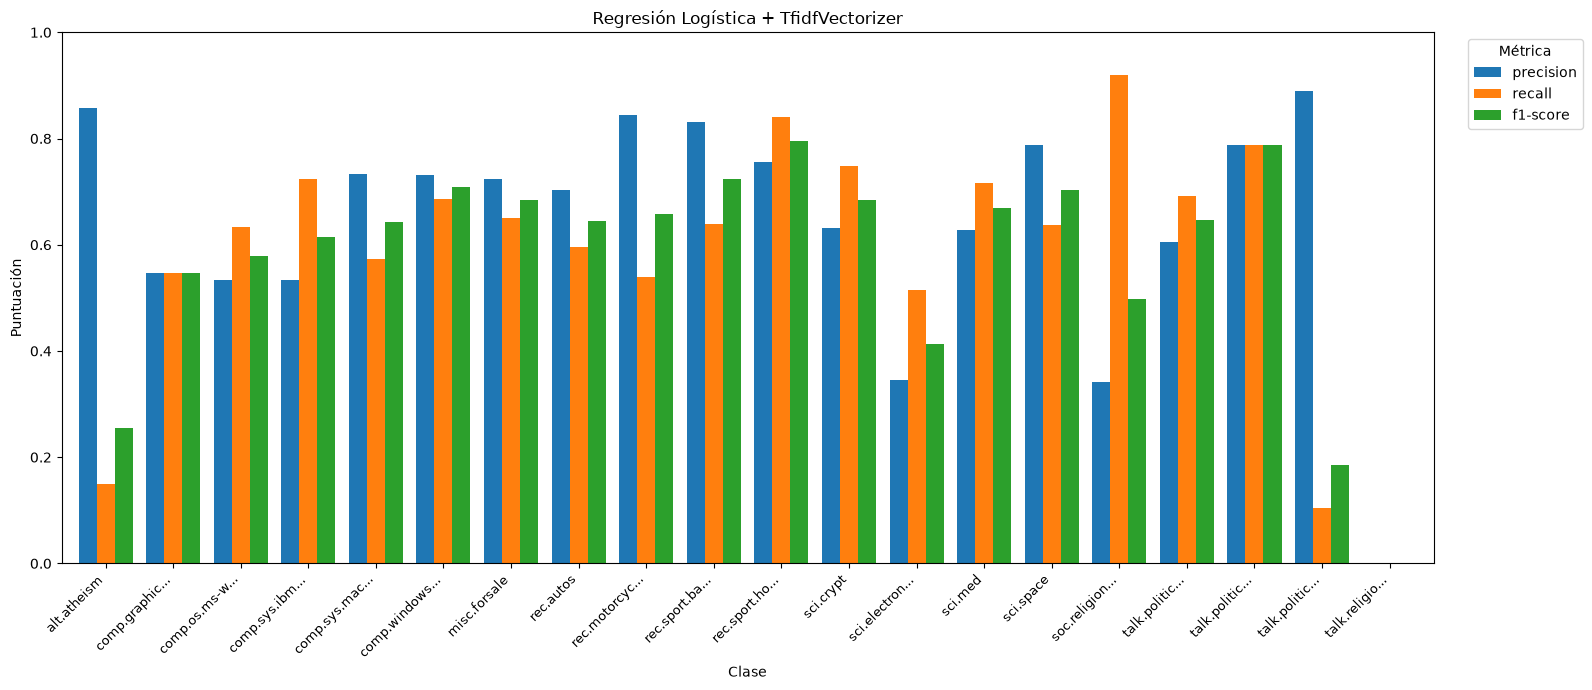

In [38]:
df_reporte_lr_tfidf = graficar_reporte_clasificacion(
    y_val,
    pred_lr_tfidf,
    "Regresión Logística + TfidfVectorizer"
)

### Comparación de los 4 modelos

In [27]:
resultados = pd.DataFrame({
    "Representación": [
        "CountVectorizer",
        "CountVectorizer",
        "TF-IDF",
        "TF-IDF"
    ],
    "Modelo": [
        "Naive Bayes",
        "Regresión logística",
        "Naive Bayes",
        "Regresión logística"
    ],
    "Accuracy_validacion": [
        acc_nb_count,
        acc_lr_count,
        acc_nb_tfidf,
        acc_lr_tfidf
    ]
})

resultados = resultados.sort_values(
    "Accuracy_validacion",
    ascending=False
).reset_index(drop=True)

resultados

,Representación,Modelo,Accuracy_validacion
0,TF-IDF,Naive Bayes,0.664191
1,CountVectorizer,Naive Bayes,0.624934
2,TF-IDF,Regresión logística,0.605305
3,CountVectorizer,Regresión logística,0.602653


In [28]:
def evaluar_modelo(
    nombre,
    modelo,
    X_train,
    X_val,
    y_train,
    y_val
):
    pred_train = modelo.predict(X_train)
    pred_val = modelo.predict(X_val)

    return {
        "Configuración": nombre,
        "Accuracy_train": accuracy_score(
            y_train,
            pred_train
        ),
        "Accuracy_validacion": accuracy_score(
            y_val,
            pred_val
        )
    }

In [29]:
resultados = [
    evaluar_modelo(
        "Count + Naive Bayes",
        nb_count,
        X_train_count,
        X_val_count,
        y_train,
        y_val
    ),

    evaluar_modelo(
        "Count + Regresión logística",
        lr_count,
        X_train_count,
        X_val_count,
        y_train,
        y_val
    ),

    evaluar_modelo(
        "TF-IDF + Naive Bayes",
        nb_tfidf,
        X_train_tfidf,
        X_val_tfidf,
        y_train,
        y_val
    ),

    evaluar_modelo(
        "TF-IDF + Regresión logística",
        lr_tfidf,
        X_train_tfidf,
        X_val_tfidf,
        y_train,
        y_val
    )
]

resultados_df = pd.DataFrame(resultados)

resultados_df = resultados_df.sort_values(
    "Accuracy_validacion",
    ascending=False
)

resultados_df

,Configuración,Accuracy_train,Accuracy_validacion
2,TF-IDF + Naive Bayes,0.768550,0.664191
0,Count + Naive Bayes,0.699036,0.624934
3,TF-IDF + Regresión logística,0.659945,0.605305
1,Count + Regresión logística,0.677545,0.602653
